# Final Project: Credit Score Classification

In [6]:

# Import necessary libraries
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# LOAD TRAIN DATA AS df
df = pd.read_csv("credit score.csv")

# BASIC EXPLORATION
print("===== SHAPE =====")
df.shape
print("\n===== COLUMNS =====")
print(df.columns)
print("\n===== INFO =====")
df.info()
print("\n===== HEAD =====")
df.head()

# CHECK MISSING VALUES
print("\n===== MISSING VALUES =====")
df.isnull().sum()


===== SHAPE =====

===== COLUMNS =====
Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month     

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

In [7]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("===== CATEGORICAL COLUMNS =====")
print(list(cat_cols))

print("\n===== UNIQUE VALUES IN EACH CATEGORICAL VARIABLE =====\n")

for col in cat_cols:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 60)


===== CATEGORICAL COLUMNS =====
['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']

===== UNIQUE VALUES IN EACH CATEGORICAL VARIABLE =====

ID:
['0x1602' '0x1603' '0x1604' ... '0x25feb' '0x25fec' '0x25fed']
------------------------------------------------------------
Customer_ID:
['CUS_0xd40' 'CUS_0x21b1' 'CUS_0x2dbc' ... 'CUS_0xaf61' 'CUS_0x8600'
 'CUS_0x942c']
------------------------------------------------------------
Month:
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August']
------------------------------------------------------------
Name:
['Aaron Maashoh' nan 'Rick Rothackerj' ... 'Chris Wickhamm'
 'Sarah McBridec' 'Nicks']
------------------------------------------------------------
Age:
[

In [8]:
import numpy as np


# CLEAN NUMERIC-LIKE COLUMNS 
# Remove letters, underscores, symbols -> convert to float
def clean_numeric(x):
    if pd.isna(x):
        return np.nan
    cleaned = "".join(ch for ch in str(x) if ch.isdigit() or ch == ".")
    return float(cleaned) if cleaned not in ["", ".", "NaN"] else np.nan


num_like_cols = [
    "Age", "Annual_Income", "Num_of_Loan",
    "Num_of_Delayed_Payment", "Changed_Credit_Limit",
    "Outstanding_Debt", "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in num_like_cols:
    df[col] = df[col].apply(clean_numeric)



# CLEAN Credit_History_Age -> convert to months (replace same column)
def convert_age_to_months(x):
    if pd.isna(x):
        return np.nan
    try:
        years = int(x.split(" Years")[0])
        months = int(x.split("and ")[1].split(" Months")[0])
        return years * 12 + months
    except:
        return np.nan

df["Credit_History_Age"] = df["Credit_History_Age"].apply(convert_age_to_months)

# CLEAN Type_of_Loan -> keep original, just remove stray commas/whitespace
df["Type_of_Loan"] = df["Type_of_Loan"].astype(str).str.strip()

# CLEAN Credit_Mix -> remove "_" only
df["Credit_Mix"] = df["Credit_Mix"].replace({"_": np.nan})

# CLEAN Payment_of_Min_Amount -> remove NM only
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace({"NM": np.nan})

# CLEAN Payment_Behaviour -> remove garbage token
df["Payment_Behaviour"] = df["Payment_Behaviour"].replace({"!@9#%8": np.nan})

# CLEAN Month column -> keep original labels
df["Month"] = df["Month"].str.strip()

# LabelEncoder will handle encoding later
print("Cleaning completed. Dataset ready for Label Encoding.")


Cleaning completed. Dataset ready for Label Encoding.


In [9]:
df=df.dropna()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38101 entries, 6 to 99997
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        38101 non-null  object 
 1   Customer_ID               38101 non-null  object 
 2   Month                     38101 non-null  object 
 3   Name                      38101 non-null  object 
 4   Age                       38101 non-null  float64
 5   SSN                       38101 non-null  object 
 6   Occupation                38101 non-null  object 
 7   Annual_Income             38101 non-null  float64
 8   Monthly_Inhand_Salary     38101 non-null  float64
 9   Num_Bank_Accounts         38101 non-null  int64  
 10  Num_Credit_Card           38101 non-null  int64  
 11  Interest_Rate             38101 non-null  int64  
 12  Num_of_Loan               38101 non-null  float64
 13  Type_of_Loan              38101 non-null  object 
 14  Delay_from_

In [11]:
# Remove irrelevant / identifier columns
drop_cols = [
    "ID", 
    "Customer_ID", 
    "Name", 
    "SSN", 
    "Occupation",
    "Type_of_Loan",              # already converted to Num_Loan_Types
    "Credit_History_Age",        # already converted to Credit_History_Months
]

df = df.drop(columns=drop_cols, errors="ignore")

print("Remaining columns after removal:\n")
print(df.columns)


Remaining columns after removal:

Index(['Month', 'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score'],
      dtype='object')


In [12]:
df.drop(df[df['Age']>85].index , axis=0 , inplace=True)


In [13]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,37026.000000,3.702600e+04,37026.000000,37026.000000,37026.000000,37026.000000,37026.000000,37026.000000,37026.000000,37026.000000,37026.000000,37026.000000,37026.000000,37026.000000,37026.000000,3.702600e+04
mean,33.350429,1.783404e+05,4163.563893,17.389483,22.482715,75.547318,10.509804,21.068087,31.602225,10.491592,27.031951,1423.461405,32.336803,1439.669423,622.354006,2.700805e+22
std,10.793804,1.438103e+06,3162.190294,120.236791,128.068577,482.523935,59.719988,14.838615,229.644531,6.671584,188.374281,1156.566556,5.096342,8365.260333,2025.601708,3.000366e+24
min,14.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.230000,20.881250,0.000000,0.000000,4.534565e-01
25%,24.000000,1.940653e+04,1623.680417,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.370000,3.000000,565.085000,28.119355,30.370735,73.188665,2.700029e+02
50%,33.000000,3.702470e+04,3073.922500,6.000000,6.000000,13.000000,3.000000,18.000000,14.000000,9.445000,6.000000,1159.430000,32.363095,68.539914,133.761928,3.361089e+02
75%,42.000000,7.260736e+04,5936.446667,7.000000,7.000000,20.000000,6.000000,28.000000,18.000000,14.850000,9.000000,1941.972500,36.545202,156.674441,259.201246,4.712737e+02
max,56.000000,2.419806e+07,15204.633333,1798.000000,1499.000000,5797.000000,1485.000000,67.000000,4397.000000,36.290000,2594.000000,4998.070000,49.564519,82204.000000,10000.000000,3.333333e+26


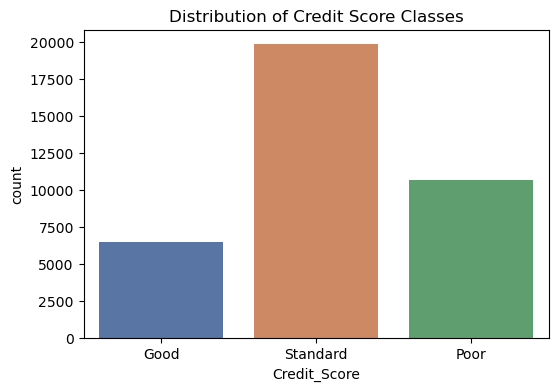

Credit_Score
Standard    53.646087
Poor        28.852698
Good        17.501215
Name: proportion, dtype: float64

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Credit_Score", palette=["#4C72B0", "#DD8452", "#55A868"] )
plt.title("Distribution of Credit Score Classes")
plt.show()

df["Credit_Score"].value_counts(normalize=True) * 100


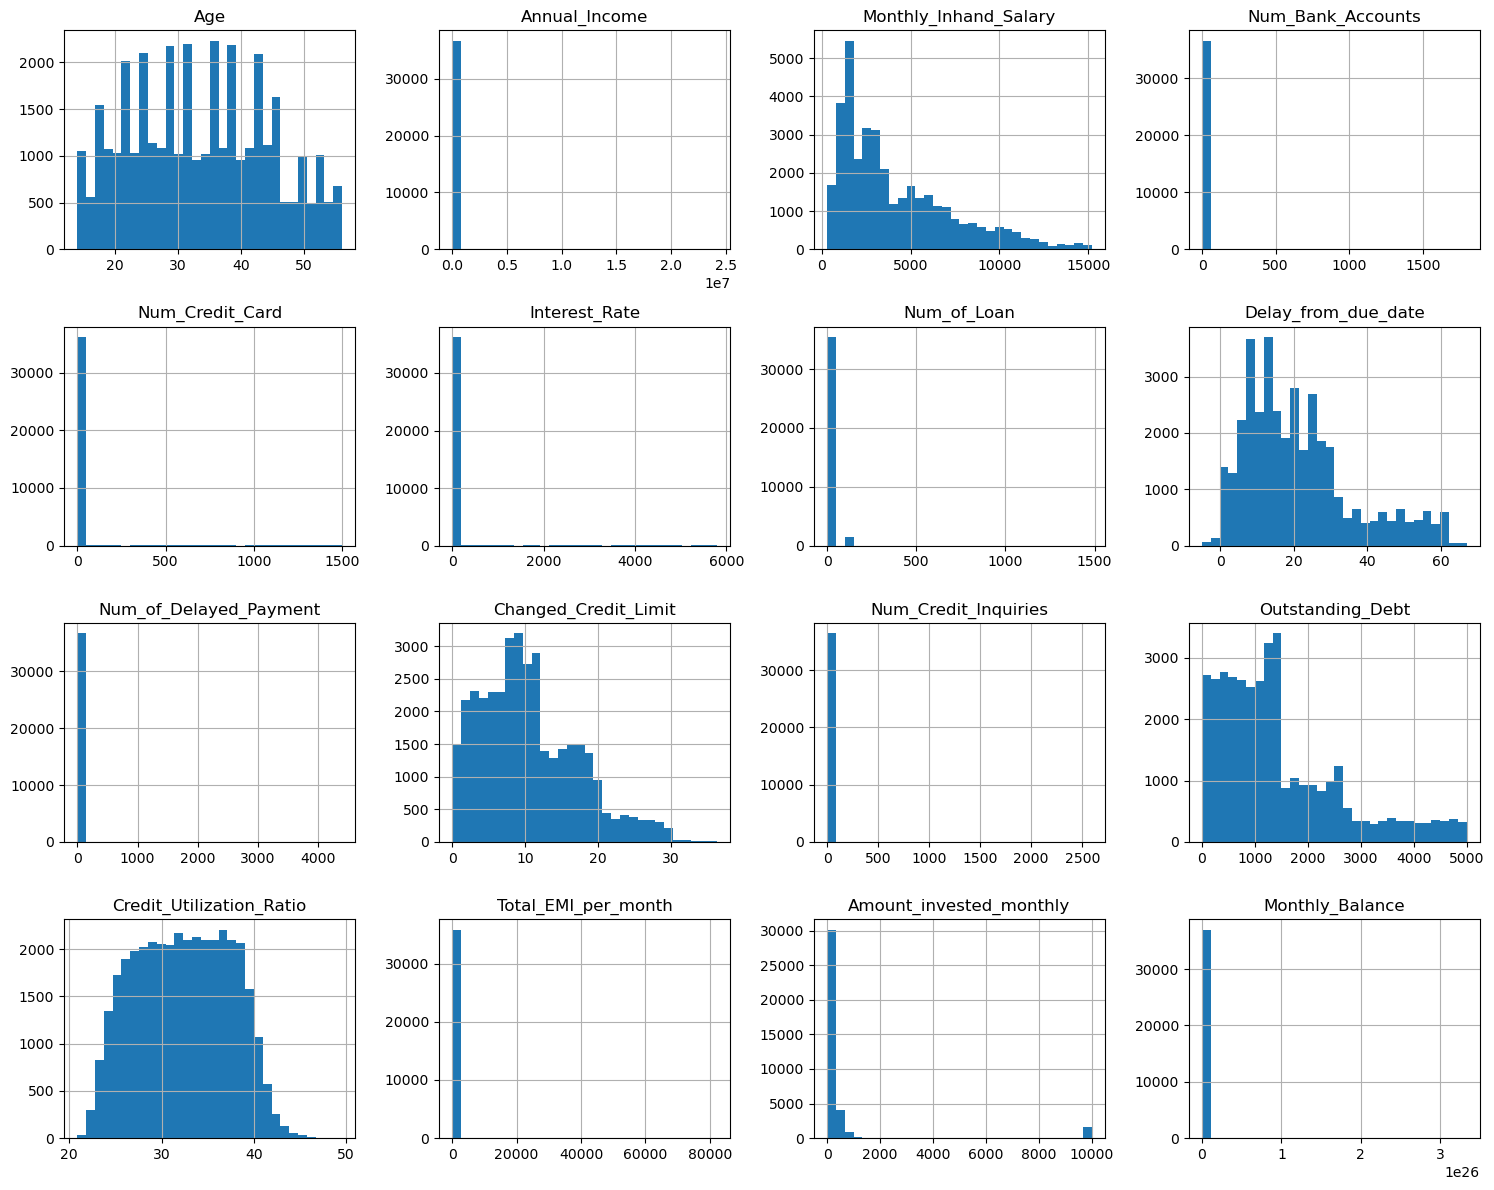

In [37]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols].hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()


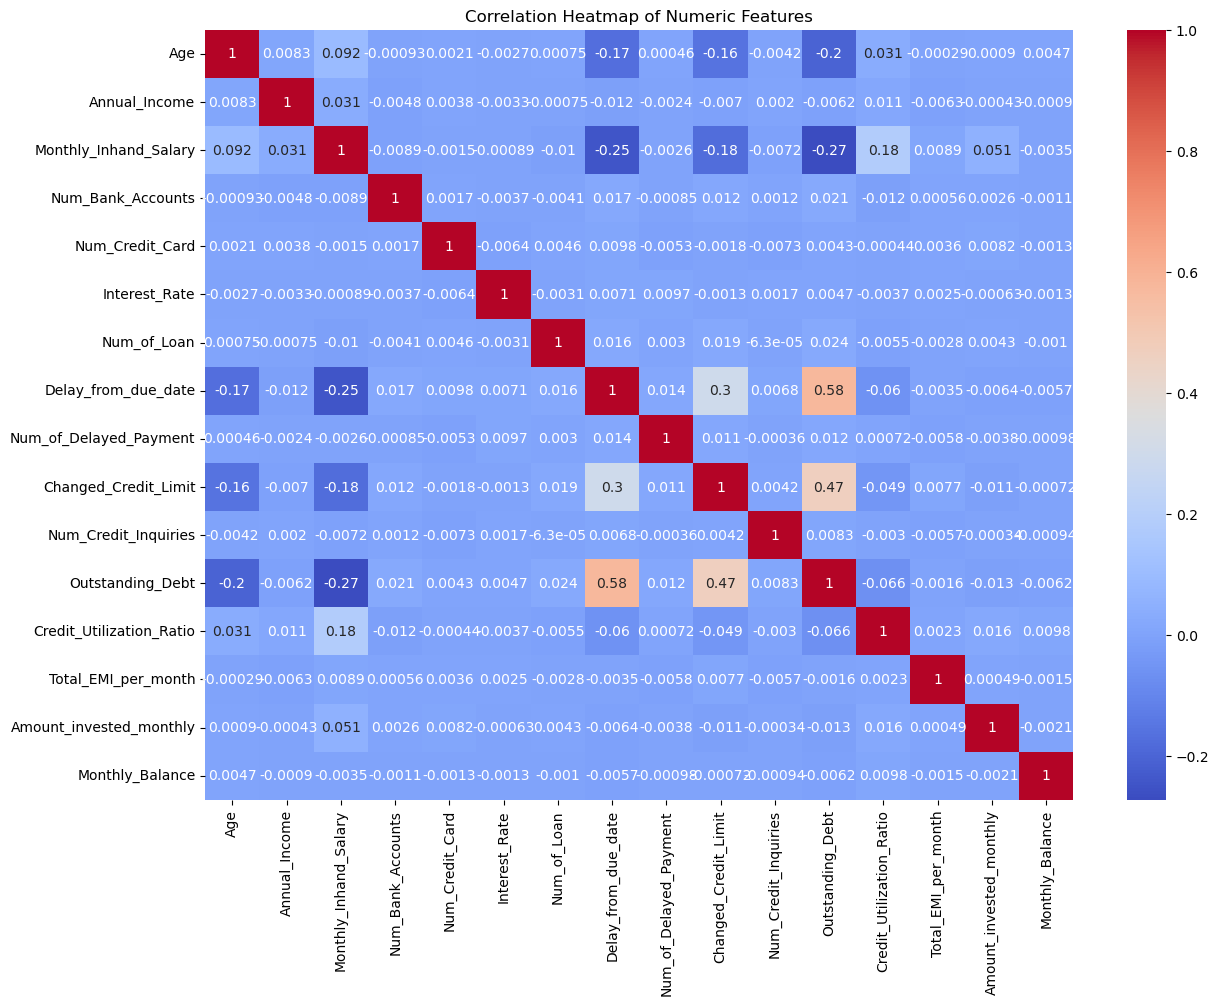

In [38]:
plt.figure(figsize=(14,10))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


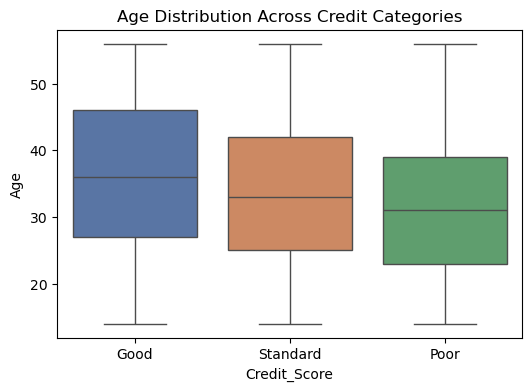

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Credit_Score", y="Age", palette=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Age Distribution Across Credit Categories")
plt.show()

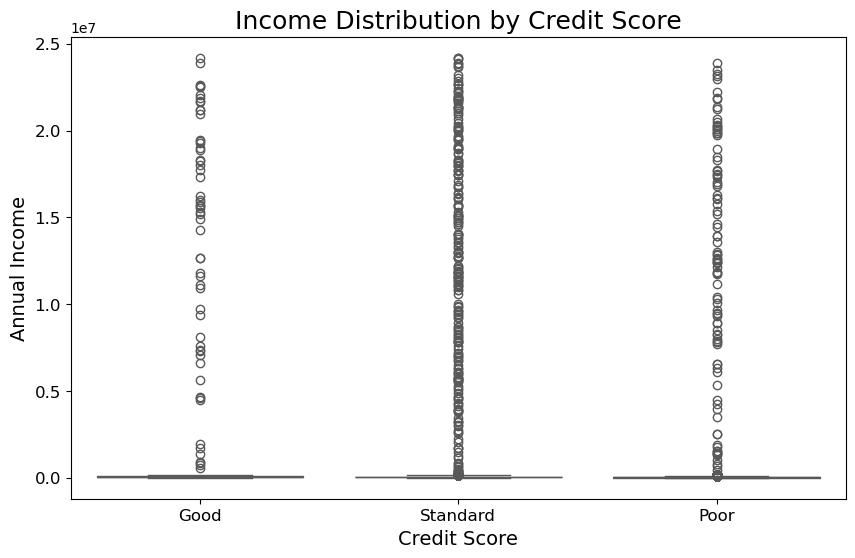

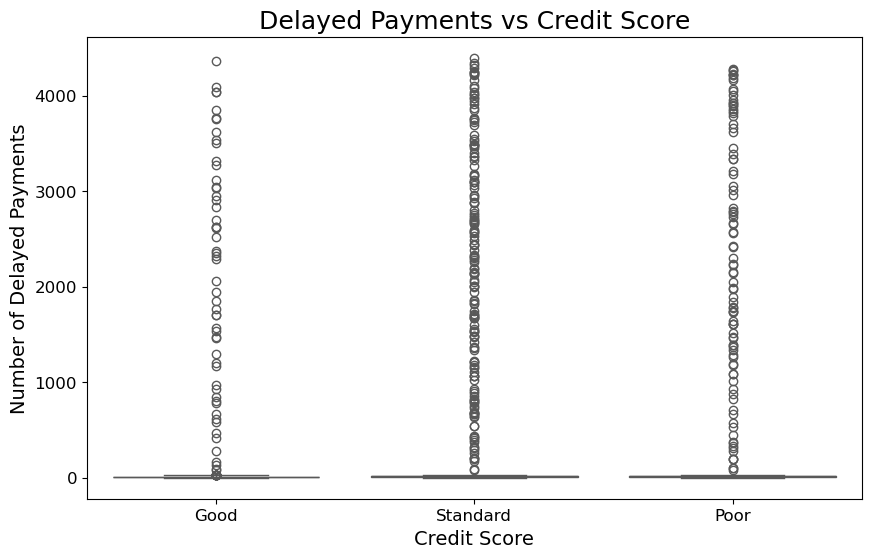

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Credit_Score", y="Annual_Income", palette="Set2")
plt.title("Income Distribution by Credit Score", fontsize=18)
plt.xlabel("Credit Score", fontsize=14)
plt.ylabel("Annual Income", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Credit_Score", y="Num_of_Delayed_Payment", palette="Set2")
plt.title("Delayed Payments vs Credit Score", fontsize=18)
plt.xlabel("Credit Score", fontsize=14)
plt.ylabel("Number of Delayed Payments", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

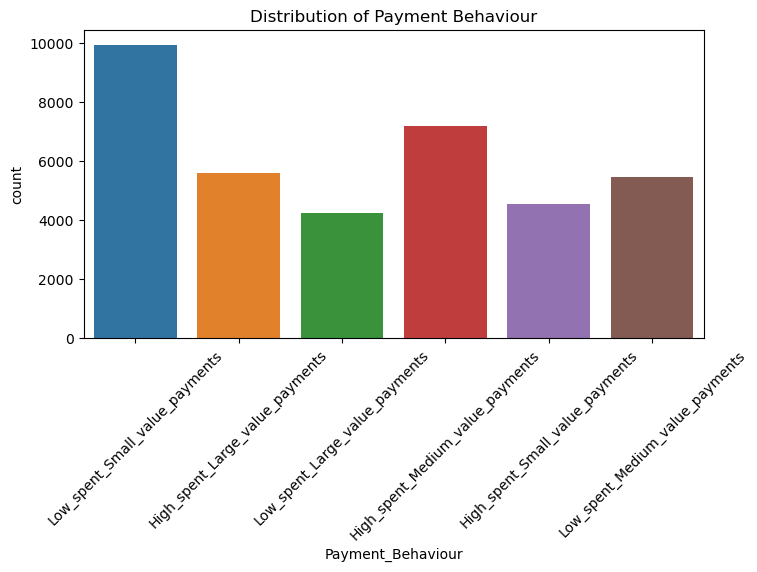

In [43]:
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']   

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Payment_Behaviour", palette=custom_colors)
plt.xticks(rotation=45)
plt.title("Distribution of Payment Behaviour")
plt.show()

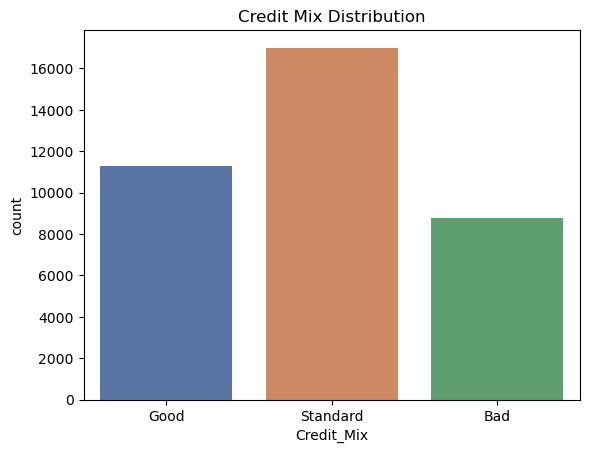

In [44]:
sns.countplot(data=df, x="Credit_Mix", palette=["#4C72B0", "#DD8452", "#55A868"] )
plt.title("Credit Mix Distribution")
plt.show()


## Model building

In [45]:
#Load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from scipy.stats import ttest_ind
from scipy.spatial.distance import mahalanobis

In [46]:
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [47]:
X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y )


In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [49]:
knn_params = {
    'n_neighbors':[3,5,7],
    'weights':['uniform','distance']
}
knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7],
                         'weights': ['uniform', 'distance']})

In [50]:
dt_params = {
    'criterion':['gini','entropy'],
    'max_depth':[5,10,15]
}
dt = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5)
dt.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 15]})

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_best.fit(X_train, y_train)


RandomForestClassifier(max_depth=15, min_samples_leaf=2, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [53]:
print(" 5-FOLD CROSS VALIDATION RESULTS ")


# KNN 
print("\n KNN Classifier (5-fold CV)")
cv_knn = cross_val_score(
    knn.best_estimator_ if hasattr(knn, "best_estimator_") else knn,
    X_train_scaled,      # KNN uses scaled data
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("CV Scores:", cv_knn)
print("Mean CV Accuracy:", cv_knn.mean())
print("Std Deviation:", cv_knn.std())


#DECISION TREE
print("\n Decision Tree Classifier (5-fold CV)")
cv_dt = cross_val_score(
    dt.best_estimator_ if hasattr(dt, "best_estimator_") else dt,
    X_train, 
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("CV Scores:", cv_dt)
print("Mean CV Accuracy:", cv_dt.mean())
print("Std Deviation:", cv_dt.std())


#RANDOM FOREST
print("\n Random Forest Classifier (5-fold CV)")
cv_rf = cross_val_score(
    rf_best,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("CV Scores:", cv_rf)
print("Mean CV Accuracy:", cv_rf.mean())
print("Std Deviation:", cv_rf.std())


 5-FOLD CROSS VALIDATION RESULTS 

 KNN Classifier (5-fold CV)
CV Scores: [0.63065496 0.63926401 0.63791357 0.6320054  0.63487508]
Mean CV Accuracy: 0.6349426063470628
Std Deviation: 0.003302023304880178

 Decision Tree Classifier (5-fold CV)
CV Scores: [0.69952735 0.7116813  0.70644835 0.69176232 0.69699527]
Mean CV Accuracy: 0.7012829169480082
Std Deviation: 0.0070273121237143625

 Random Forest Classifier (5-fold CV)
CV Scores: [0.73717083 0.74831195 0.74105334 0.7258609  0.72889939]
Mean CV Accuracy: 0.736259284267387
Std Deviation: 0.008140945883287846


## OOD Samples

In [54]:
continuous_features = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Interest_Rate",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

In [55]:
# Create OOD version of X_test
X_test_ood = X_test.copy()

noise_strength = 0.5  # Increase to 1.0 or 1.5 for more drift

for col in continuous_features:
    col_std = X_test[col].std()
    noise = np.random.normal(loc=0, scale=col_std * noise_strength, size=X_test.shape[0])
    X_test_ood[col] = X_test[col] + noise

# Scale OOD for KNN only
X_test_ood_scaled = scaler.transform(X_test_ood)


In [56]:
from scipy.stats import ks_2samp

ks_results = {}

for col in X.columns:
    stat, p = ks_2samp(X_test[col], X_test_ood[col])
    ks_results[col] = {"KS_statistic": stat, "p_value": p}

ks_df = pd.DataFrame(ks_results).T.sort_values("KS_statistic", ascending=False)
print(ks_df)


                          KS_statistic       p_value
Total_EMI_per_month           0.473265  0.000000e+00
Interest_Rate                 0.469754  0.000000e+00
Annual_Income                 0.468944  0.000000e+00
Num_of_Delayed_Payment        0.453011  0.000000e+00
Amount_invested_monthly       0.406832  0.000000e+00
Monthly_Inhand_Salary         0.116662  2.685152e-44
Outstanding_Debt              0.102349  3.558737e-34
Monthly_Balance               0.095058  1.569299e-29
Delay_from_due_date           0.071023  1.158594e-16
Changed_Credit_Limit          0.063462  2.184857e-13
Age                           0.047799  8.914216e-08
Credit_Utilization_Ratio      0.040508  1.052596e-05
Num_Credit_Inquiries          0.000000  1.000000e+00
Credit_Mix                    0.000000  1.000000e+00
Num_of_Loan                   0.000000  1.000000e+00
Payment_of_Min_Amount         0.000000  1.000000e+00
Num_Credit_Card               0.000000  1.000000e+00
Num_Bank_Accounts             0.000000  1.0000

In [57]:
top_ood_features = ks_df.head(5).index.tolist()
top_ood_features


['Total_EMI_per_month',
 'Interest_Rate',
 'Annual_Income',
 'Num_of_Delayed_Payment',
 'Amount_invested_monthly']

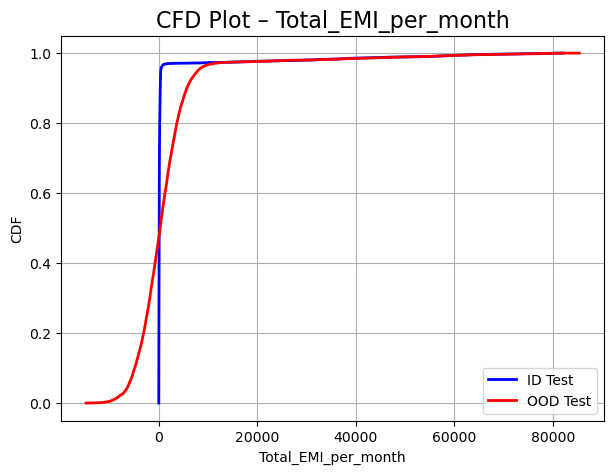

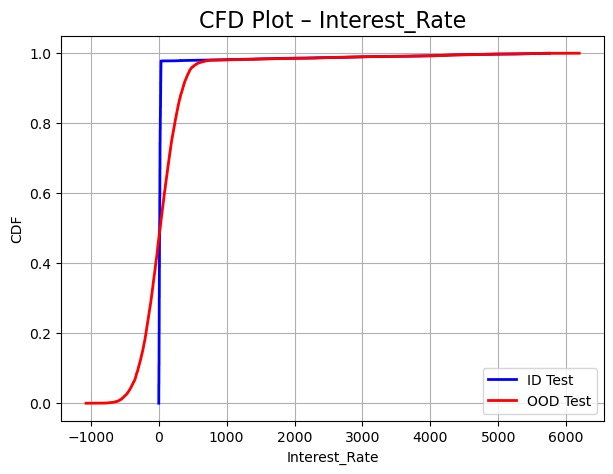

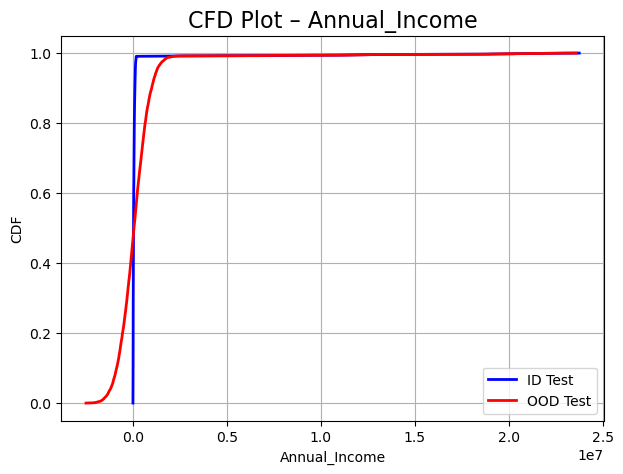

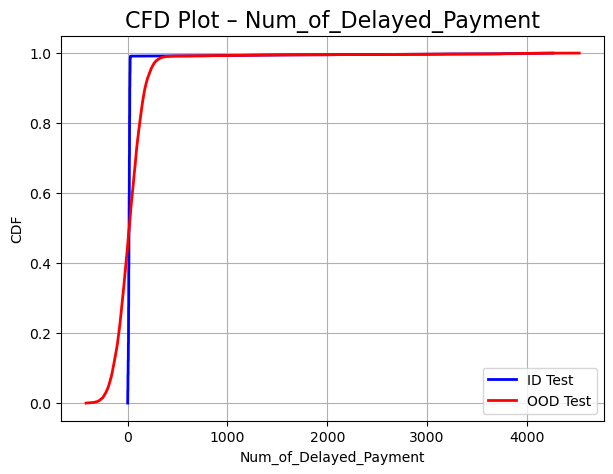

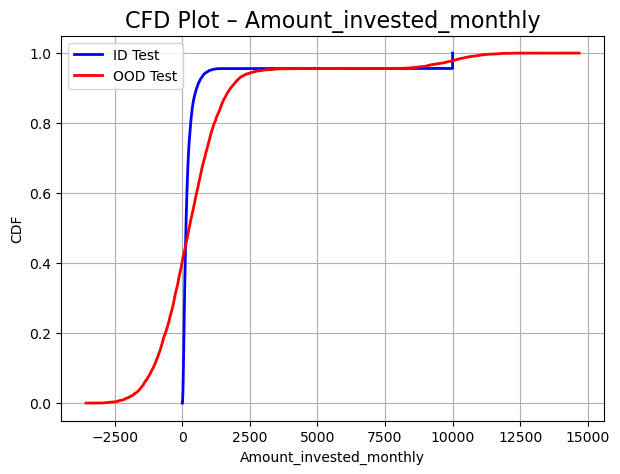

In [58]:
from statsmodels.distributions.empirical_distribution import ECDF

for feature in top_ood_features:
    plt.figure(figsize=(7,5))

    ecdf_id = ECDF(X_test[feature])
    ecdf_ood = ECDF(X_test_ood[feature])

    # Different colors
    plt.plot(ecdf_id.x, ecdf_id.y, label="ID Test", linewidth=2, color="blue")
    plt.plot(ecdf_ood.x, ecdf_ood.y, label="OOD Test", linewidth=2, color="red")

    plt.title(f"CFD Plot – {feature}", fontsize=16)
    plt.xlabel(feature)
    plt.ylabel("CDF")
    plt.legend()
    plt.grid(True)
    plt.show()


In [59]:
# Recreate models if missing
models = {
    "KNN": knn.best_estimator_ if hasattr(knn, "best_estimator_") else knn,
    "Decision Tree": dt.best_estimator_ if hasattr(dt, "best_estimator_") else dt,
    "Random Forest": rf_best
}

def predict_model(model_name, model, X_scaled, X_unscaled):
    if model_name == "KNN":
        return model.predict(X_scaled)
    else:
        return model.predict(X_unscaled)


       MODEL: KNN — ID TEST EVALUATION


<Figure size 600x400 with 0 Axes>

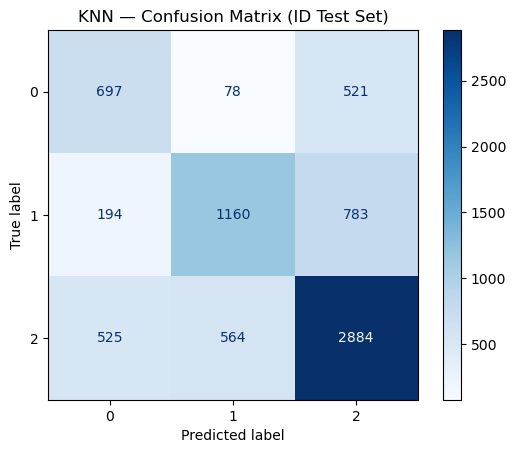


Classification Report (ID Test Set):
              precision    recall  f1-score   support

           0       0.49      0.54      0.51      1296
           1       0.64      0.54      0.59      2137
           2       0.69      0.73      0.71      3973

    accuracy                           0.64      7406
   macro avg       0.61      0.60      0.60      7406
weighted avg       0.64      0.64      0.64      7406

       MODEL: Decision Tree — ID TEST EVALUATION


<Figure size 600x400 with 0 Axes>

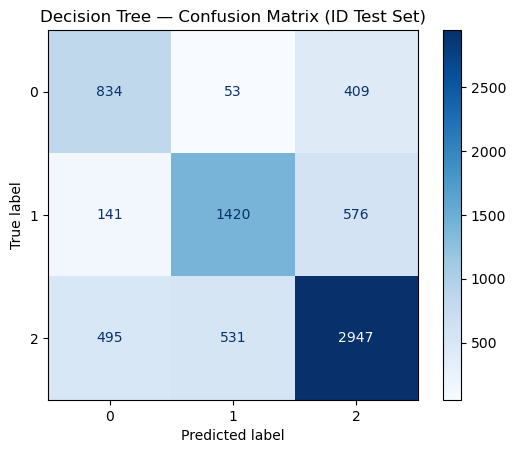


Classification Report (ID Test Set):
              precision    recall  f1-score   support

           0       0.57      0.64      0.60      1296
           1       0.71      0.66      0.69      2137
           2       0.75      0.74      0.75      3973

    accuracy                           0.70      7406
   macro avg       0.68      0.68      0.68      7406
weighted avg       0.71      0.70      0.70      7406

       MODEL: Random Forest — ID TEST EVALUATION


<Figure size 600x400 with 0 Axes>

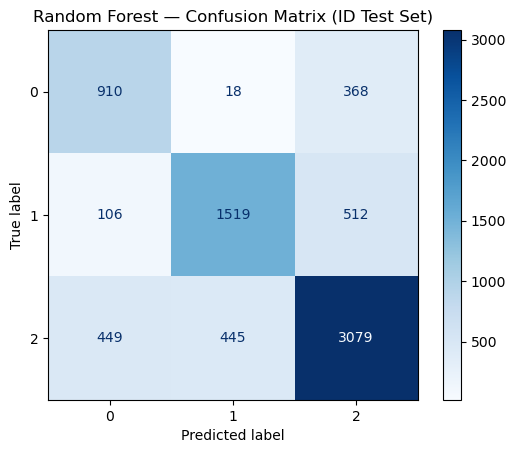


Classification Report (ID Test Set):
              precision    recall  f1-score   support

           0       0.62      0.70      0.66      1296
           1       0.77      0.71      0.74      2137
           2       0.78      0.77      0.78      3973

    accuracy                           0.74      7406
   macro avg       0.72      0.73      0.72      7406
weighted avg       0.75      0.74      0.74      7406



In [62]:
# ID evaluation (full features)
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

for name, model in models.items():
    
    print(f"       MODEL: {name} — ID TEST EVALUATION")
    

    # ID predictions
    y_pred_id = predict_model(name, model, X_test_scaled, X_test)

    # Confusion matrix ID
    plt.figure(figsize=(6,4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_id, cmap="Blues")
    plt.title(f"{name} — Confusion Matrix (ID Test Set)")
    plt.show()

    # Classification Report ID
    print("\nClassification Report (ID Test Set):")
    print(classification_report(y_test, y_pred_id))


 RE-TRAINED MODELS — OOD TEST EVALUATION (REDUCED FEATURES)
       MODEL: KNN — OOD TEST (REDUCED FEATURES)


<Figure size 600x400 with 0 Axes>

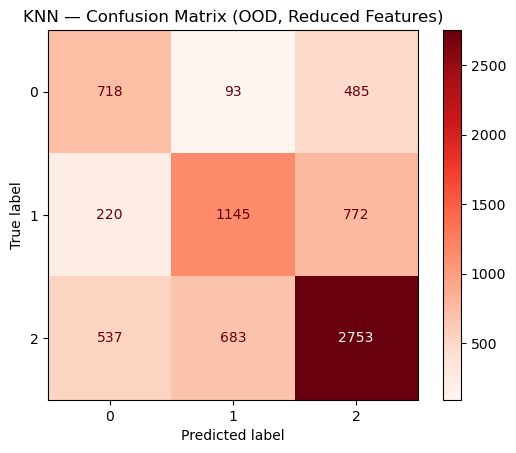


Classification Report (OOD Test Set):
              precision    recall  f1-score   support

           0       0.49      0.55      0.52      1296
           1       0.60      0.54      0.56      2137
           2       0.69      0.69      0.69      3973

    accuracy                           0.62      7406
   macro avg       0.59      0.59      0.59      7406
weighted avg       0.63      0.62      0.62      7406

       MODEL: Decision Tree — OOD TEST (REDUCED FEATURES)


<Figure size 600x400 with 0 Axes>

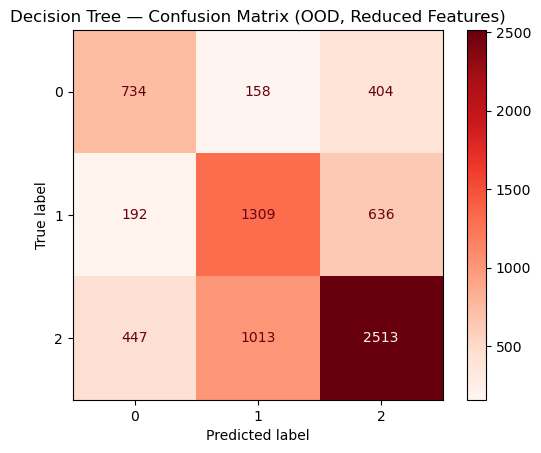


Classification Report (OOD Test Set):
              precision    recall  f1-score   support

           0       0.53      0.57      0.55      1296
           1       0.53      0.61      0.57      2137
           2       0.71      0.63      0.67      3973

    accuracy                           0.62      7406
   macro avg       0.59      0.60      0.59      7406
weighted avg       0.63      0.62      0.62      7406

       MODEL: Random Forest — OOD TEST (REDUCED FEATURES)


<Figure size 600x400 with 0 Axes>

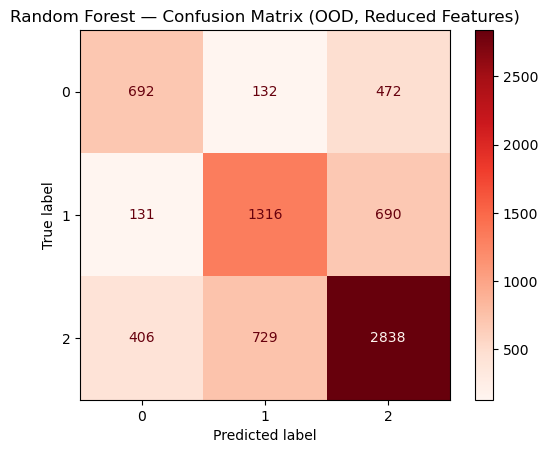


Classification Report (OOD Test Set):
              precision    recall  f1-score   support

           0       0.56      0.53      0.55      1296
           1       0.60      0.62      0.61      2137
           2       0.71      0.71      0.71      3973

    accuracy                           0.65      7406
   macro avg       0.63      0.62      0.62      7406
weighted avg       0.65      0.65      0.65      7406



In [64]:
# Remove OOD-shifted features
X_train_reduced     = X_train.drop(columns=top_ood_features)
X_test_reduced      = X_test.drop(columns=top_ood_features)
X_test_ood_reduced  = X_test_ood.drop(columns=top_ood_features)

# Fit scaler on reduced training set
scaler_reduced = StandardScaler()
X_train_scaled_reduced = scaler_reduced.fit_transform(X_train_reduced)
X_test_scaled_reduced  = scaler_reduced.transform(X_test_reduced)
X_test_ood_scaled_reduced = scaler_reduced.transform(X_test_ood_reduced)
knn_retrained = KNeighborsClassifier(
    n_neighbors=knn.best_estimator_.n_neighbors
)
knn_retrained.fit(X_train_scaled_reduced, y_train)
dt_retrained = DecisionTreeClassifier(
    max_depth=dt.best_estimator_.max_depth,
    criterion=dt.best_estimator_.criterion
)
dt_retrained.fit(X_train_reduced, y_train)
rf_retrained = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_retrained.fit(X_train_reduced, y_train)
models_retrained = {
    "KNN": knn_retrained,
    "Decision Tree": dt_retrained,
    "Random Forest": rf_retrained
}

print(" RE-TRAINED MODELS — OOD TEST EVALUATION (REDUCED FEATURES)")

for name, model in models_retrained.items():

    print(f"       MODEL: {name} — OOD TEST (REDUCED FEATURES)")

    # OOD predictions
    if name == "KNN":
        y_pred_ood = model.predict(X_test_ood_scaled_reduced)
    else:
        y_pred_ood = model.predict(X_test_ood_reduced)

    # Confusion matrix OOD
    plt.figure(figsize=(6,4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ood, cmap="Reds")
    plt.title(f"{name} — Confusion Matrix (OOD, Reduced Features)")
    plt.show()

    # Classification Report
    print("\nClassification Report (OOD Test Set):")
    print(classification_report(y_test, y_pred_ood))


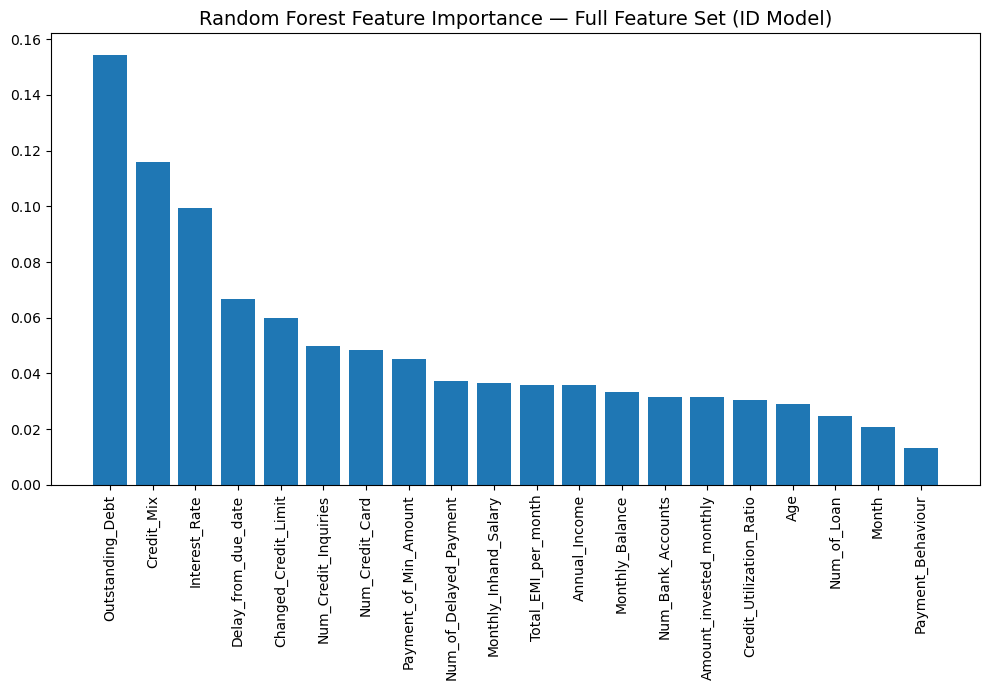

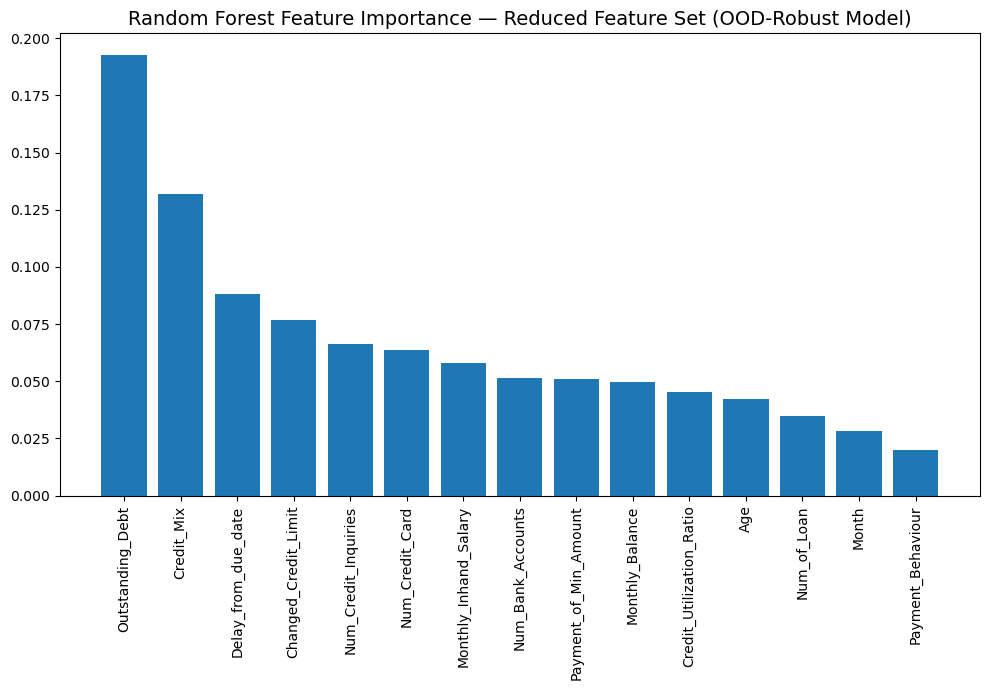

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. FEATURE IMPORTANCE (ID Model)
importances_full = rf_best.feature_importances_
features_full = X_train.columns

# Sort importances
indices_full = np.argsort(importances_full)[::-1]

plt.figure(figsize=(10,7))
plt.title("Random Forest Feature Importance — Full Feature Set (ID Model)", fontsize=14)
plt.bar(range(len(features_full)), importances_full[indices_full])
plt.xticks(range(len(features_full)), features_full[indices_full], rotation=90)
plt.tight_layout()
plt.show()


# 2. FEATURE IMPORTANCE (OOD-Retrained Model)
importances_reduced = rf_retrained.feature_importances_
features_reduced = X_train_reduced.columns

# Sort importances
indices_reduced = np.argsort(importances_reduced)[::-1]

plt.figure(figsize=(10,7))
plt.title("Random Forest Feature Importance — Reduced Feature Set (OOD-Robust Model)", fontsize=14)
plt.bar(range(len(features_reduced)), importances_reduced[indices_reduced])
plt.xticks(range(len(features_reduced)), features_reduced[indices_reduced], rotation=90)
plt.tight_layout()
plt.show()


CONFIDENCE ANALYSIS — KNN

ID Confidence:
  Mean:   0.7107
  Median: 0.7104
  Std:    0.1729

OOD Confidence:
  Mean:   0.7032
  Median: 0.7112
  Std:    0.1703


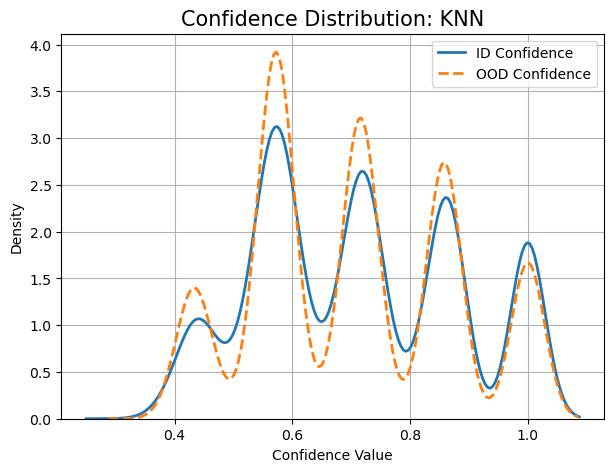

CONFIDENCE ANALYSIS — Decision Tree

ID Confidence:
  Mean:   0.7033
  Median: 0.7697
  Std:    0.1544

OOD Confidence:
  Mean:   0.6996
  Median: 0.6968
  Std:    0.1458


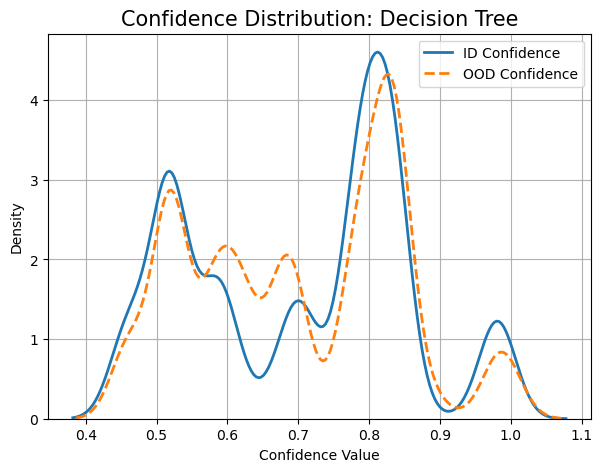

CONFIDENCE ANALYSIS — Random Forest

ID Confidence:
  Mean:   0.6984
  Median: 0.7233
  Std:    0.1615

OOD Confidence:
  Mean:   0.5515
  Median: 0.5378
  Std:    0.1004


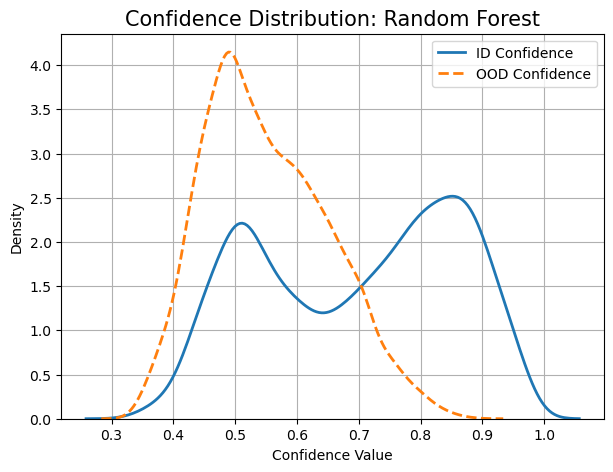

In [66]:
def get_confidence(model, model_name, X_scaled, X_unscaled):
    # KNN uses scaled features
    if model_name == "KNN":
        probs = model.predict_proba(X_scaled)
    else:
        probs = model.predict_proba(X_unscaled)
    
    confidence = probs.max(axis=1)   # highest probability among classes
    return confidence, probs
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():

    print(f"CONFIDENCE ANALYSIS — {name}")

    # ID Confidence
    conf_id, _ = get_confidence(model, name, X_test_scaled, X_test)

    # OOD Confidence
    conf_ood, _ = get_confidence(model, name, X_test_ood_scaled, X_test_ood)

    # Summary statistics
    print("\nID Confidence:")
    print(f"  Mean:   {conf_id.mean():.4f}")
    print(f"  Median: {np.median(conf_id):.4f}")
    print(f"  Std:    {conf_id.std():.4f}")

    print("\nOOD Confidence:")
    print(f"  Mean:   {conf_ood.mean():.4f}")
    print(f"  Median: {np.median(conf_ood):.4f}")
    print(f"  Std:    {conf_ood.std():.4f}")

    # Plot confidence distributions
    plt.figure(figsize=(7,5))
    sns.kdeplot(conf_id, label="ID Confidence", linewidth=2)
    sns.kdeplot(conf_ood, label="OOD Confidence", linewidth=2, linestyle="--")
    plt.title(f"Confidence Distribution: {name}", fontsize=15)
    plt.xlabel("Confidence Value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()
